# Phase 3: Exploratory Data Analysis (EDA)

The objective of this phase is to uncover underlying patterns, temporal trends, and feature relationships to inform the multi-class classification modeling decisions. This notebook contains both univariate and bivariate analyses using visual and statistical evidence to address the core research questions.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Univariate Analysis: Top 12 Operating Companies

This horizontal bar chart maps the operator profiles by isolating the top twelve companies by reported spill count.

**Observation:** The chart reveals a heavily skewed distribution where the top two companies, NAOC and SPDC account for a disproportionate majority of the total reported oil spills, while the remaining operators in the top 12 show significantly lower incident frequencies.

/tmp/ipykernel_2221/3907706756.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


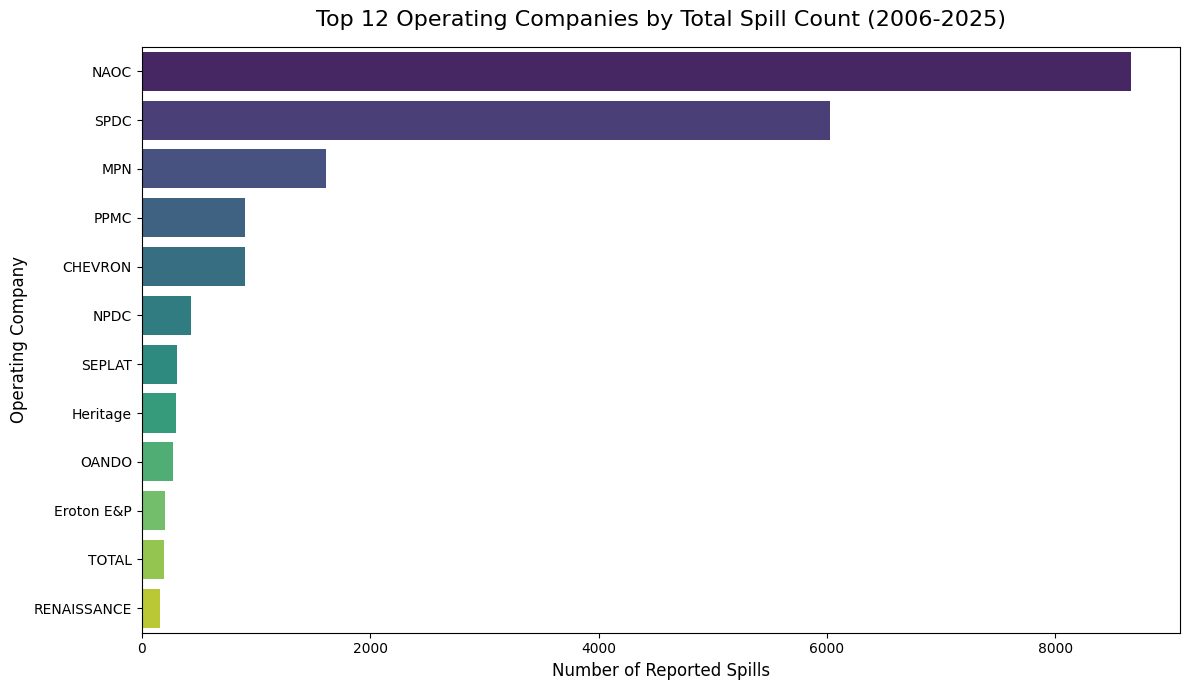

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

file_path = "/content/drive/MyDrive/nosdra_2026-08-23_15_32_02UTC_complete.csv"
df = pd.read_csv(file_path, on_bad_lines='skip')

# Ensure the output directory exists
os.makedirs('reports/figures', exist_ok=True)

# 2. Isolate the top 12 companies by spill count
top_12_companies = df['company'].value_counts().nlargest(12)

# 3. Set up the matplotlib figure
plt.figure(figsize=(12, 7))

# 4. Create a horizontal bar chart using seaborn
sns.barplot(
    x=top_12_companies.values,
    y=top_12_companies.index,
    palette='viridis'
)

plt.title('Top 12 Operating Companies by Total Spill Count (2006-2025)', fontsize=16, pad=15)
plt.xlabel('Number of Reported Spills', fontsize=12)
plt.ylabel('Operating Company', fontsize=12)

# 6. Save the figure for Chapter 4 of your SIWES report
plt.tight_layout()
plt.savefig('reports/figures/01_top_12_companies.png', dpi=300)

plt.show()

In [8]:
import numpy as np

# 1. Convert estimatedquantity to numerical data (forces text errors to NaN)
df['estimatedquantity'] = pd.to_numeric(df['estimatedquantity'], errors='coerce')

# 2. Define a function to categorize severity based on barrel volume thresholds
def categorize_severity(row):
    qty = row['estimatedquantity']
    habitat = str(row.get('spillareahabitat', '')).lower()

    # Handle missing quantities
    if pd.isna(qty):
        return 'Unknown'

    # Inland water thresholds
    if 'inland' in habitat:
        if qty > 250: return 'Major'
        elif qty >= 25: return 'Medium'
        else: return 'Minor'

    # Standard thresholds for land, swamp, shoreline, open sea
    else:
        if qty > 2500: return 'Major'
        elif qty >= 250: return 'Medium'
        else: return 'Minor'

# 3. Apply the logic to create the new target column
df['severity'] = df.apply(categorize_severity, axis=1)

# 4. Verify the new column distribution
print(df['severity'].value_counts())

severity
Minor      12678
Unknown     7905
Medium       472
Major         52
Name: count, dtype: int64


### 2. Bivariate Analysis: Top Causes vs. Severity

This stacked bar chart evaluates the relationship between the reported causes of spills and their resulting severity categories (Major, Medium, and Minor)[cite: 2].

**Observation:** Sabotage and equipment failure emerge as the dominant causes of oil spills. Across all top reported causes, 'Minor' severity spills overwhelmingly constitute the vast majority of incidents, while 'Major' and 'Medium' spills remain a minimal fraction.

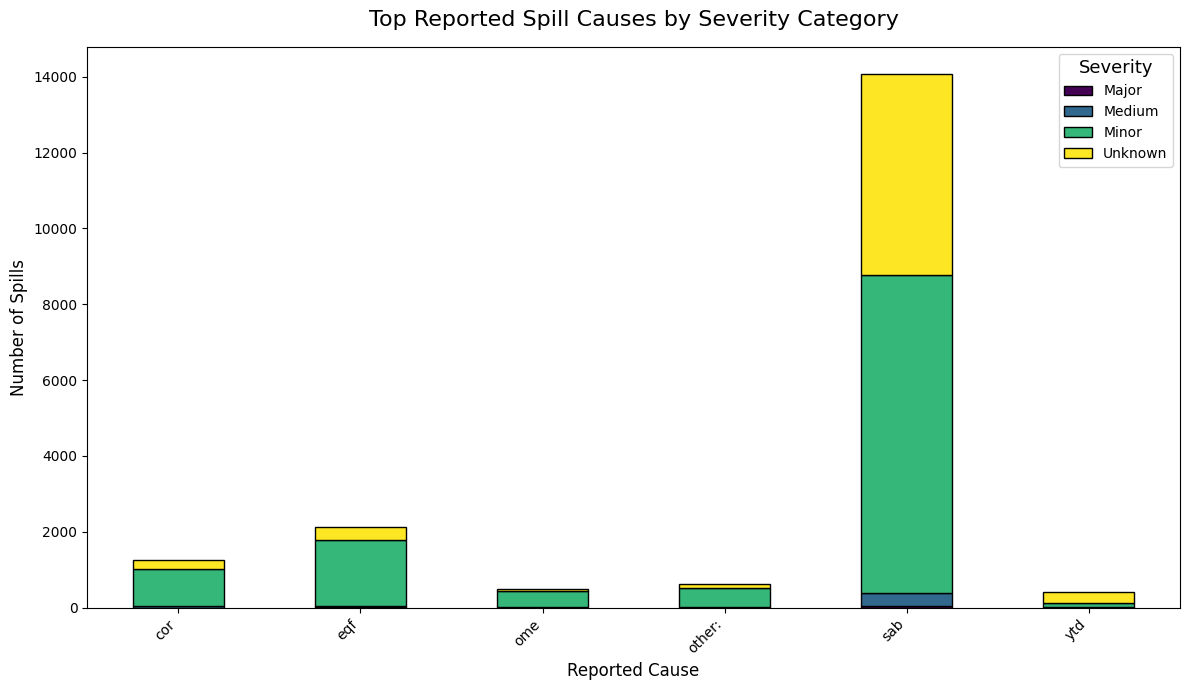

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs('reports/figures', exist_ok=True)

# 1. Filter for the top 6 causes to avoid visual clutter
top_causes = df['cause'].value_counts().nlargest(6).index
df_filtered = df[df['cause'].isin(top_causes)]

# 2. Creating a cross-tabulation of Cause vs. Severity
cause_severity_crosstab = pd.crosstab(df_filtered['cause'], df_filtered['severity'])

# 3. Plotting the stacked bar chart
ax = cause_severity_crosstab.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='viridis',
    edgecolor='black'
)

# 4. Adding professional labeling for the report
plt.title('Top Reported Spill Causes by Severity Category', fontsize=16, pad=15)
plt.xlabel('Reported Cause', fontsize=12)
plt.ylabel('Number of Spills', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity', title_fontsize='13', loc='upper right')

plt.tight_layout()
plt.savefig('reports/figures/02_cause_vs_severity.png', dpi=300)
plt.show()

## 3. Overall Severity Distribution of Reported Oil Spills

### 3. Class Imbalance Assessment: Severity Distribution

This section quantifies the proportion of each severity class using both a bar chart and a pie chart[cite: 2]. The severity target variable was engineered using official NOSDRA thresholds, which define major, medium, and minor spills based on barrel volume and habitat[cite: 3].

**Observation:** The visualizations confirm a severe class imbalance. 'Minor' spills strongly dominate the dataset with 12,678 incidents, followed by a large portion of 'Unknown' spills (7,905). In stark contrast, 'Medium' (472) and 'Major' (52) spills are exceptionally rare. This imbalance will require class weighting or resampling during the predictive modeling phase

/tmp/ipykernel_2221/3182730911.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


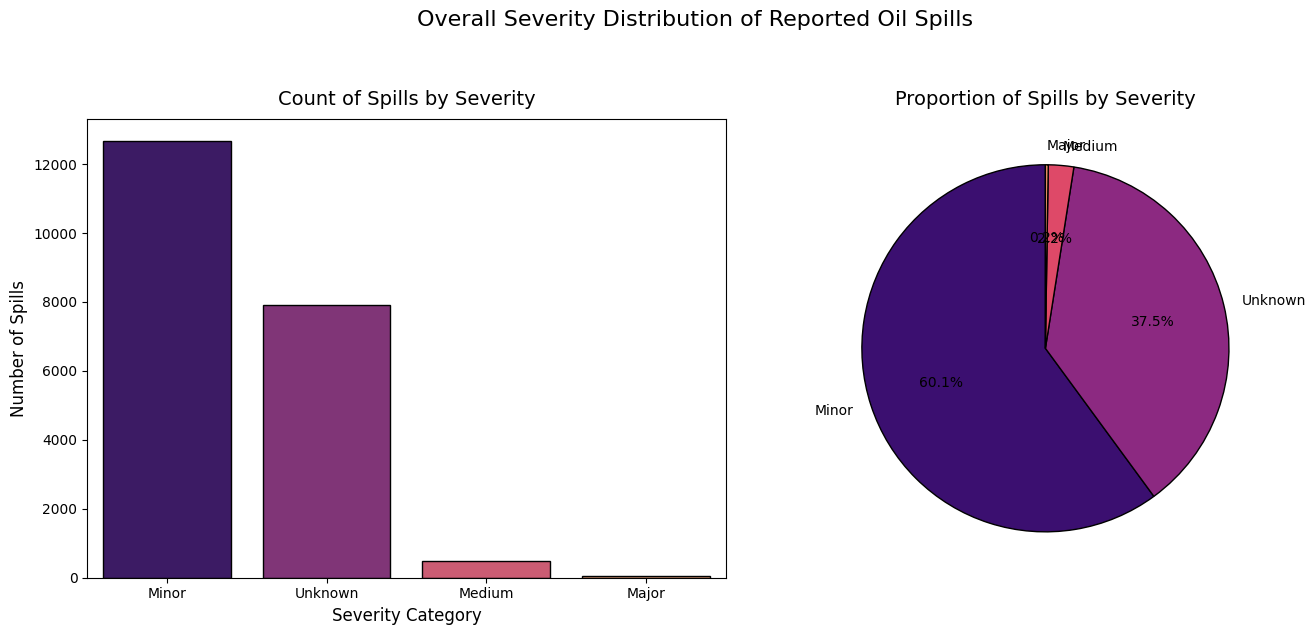

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('reports/figures', exist_ok=True)

# 1. Calculating the distribution of the severity categories
severity_counts = df['severity'].value_counts()

# 2. Setting up a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 3. Plotting the Bar Chart on the left
sns.barplot(
    x=severity_counts.index,
    y=severity_counts.values,
    palette='magma',
    ax=ax1,
    edgecolor='black'
)
ax1.set_title('Count of Spills by Severity', fontsize=14, pad=10)
ax1.set_xlabel('Severity Category', fontsize=12)
ax1.set_ylabel('Number of Spills', fontsize=12)

# 4. Plotting the Pie Chart on the right
ax2.pie(
    severity_counts.values,
    labels=severity_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('magma', len(severity_counts)),
    wedgeprops={'edgecolor': 'black'}
)
ax2.set_title('Proportion of Spills by Severity', fontsize=14, pad=10)

plt.suptitle('Overall Severity Distribution of Reported Oil Spills', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('reports/figures/03_severity_distribution.png', dpi=300)

plt.show()

### 4. Temporal Analysis: Spills per Year by Severity

This stacked chart maps the historical timeline of oil spills from 2006 onward, illustrating both the frequency of incidents over time and the year-over-year severity distribution[cite: 2].

**Observation:** There is a noticeable spike in reported incidents in years 2013 and 2014, though the proportion of Major spills remains consistently low over the timeline.

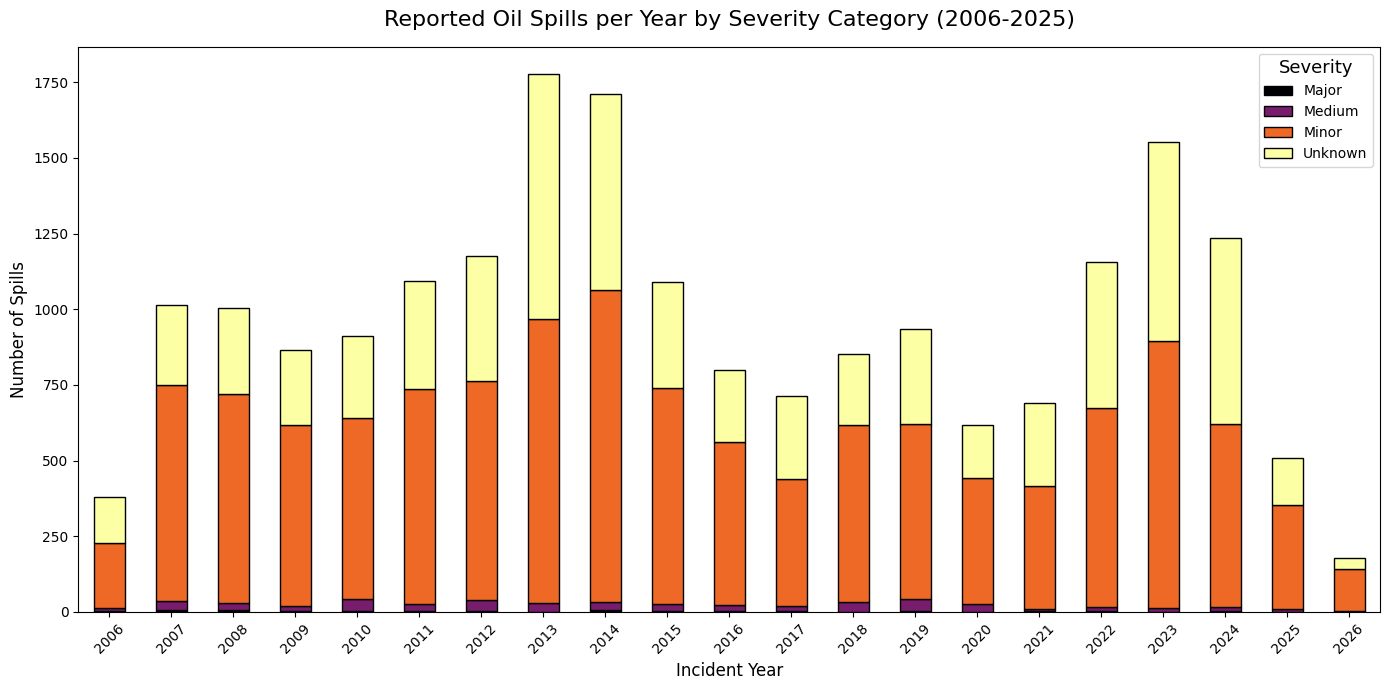

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs('reports/figures', exist_ok=True)

# 1. Converting 'incidentdate' to datetime objects to extract the year
df['incident_year'] = pd.to_datetime(df['incidentdate'], errors='coerce').dt.year

# 2. Filtering out missing dates
df_years = df[df['incident_year'] >= 2006].copy()
df_years['incident_year'] = df_years['incident_year'].astype(int)

# 3. Creating a cross-tabulation of Year vs. Severity
year_severity_crosstab = pd.crosstab(df_years['incident_year'], df_years['severity'])

# 4. Plotting the stacked bar chart
year_severity_crosstab.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='inferno',
    edgecolor='black'
)

# 5. Adding professional titles and labels
plt.title('Reported Oil Spills per Year by Severity Category (2006-2025)', fontsize=16, pad=15)
plt.xlabel('Incident Year', fontsize=12)
plt.ylabel('Number of Spills', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Severity', title_fontsize='13', loc='upper right')

plt.tight_layout()
plt.savefig('reports/figures/04_spills_per_year.png', dpi=300)

plt.show()

### 5. Bivariate Analysis: JIV Status vs. Severity

This chart compares the Joint Investigation Visit (JIV) status against the severity categories to determine if formal site assessments correlate with specific severity classifications[cite: 2].

**Observation:** [Insert your observation here, e.g., The data shows that the vast majority of categorized spills received a formal Joint Investigation Visit.]

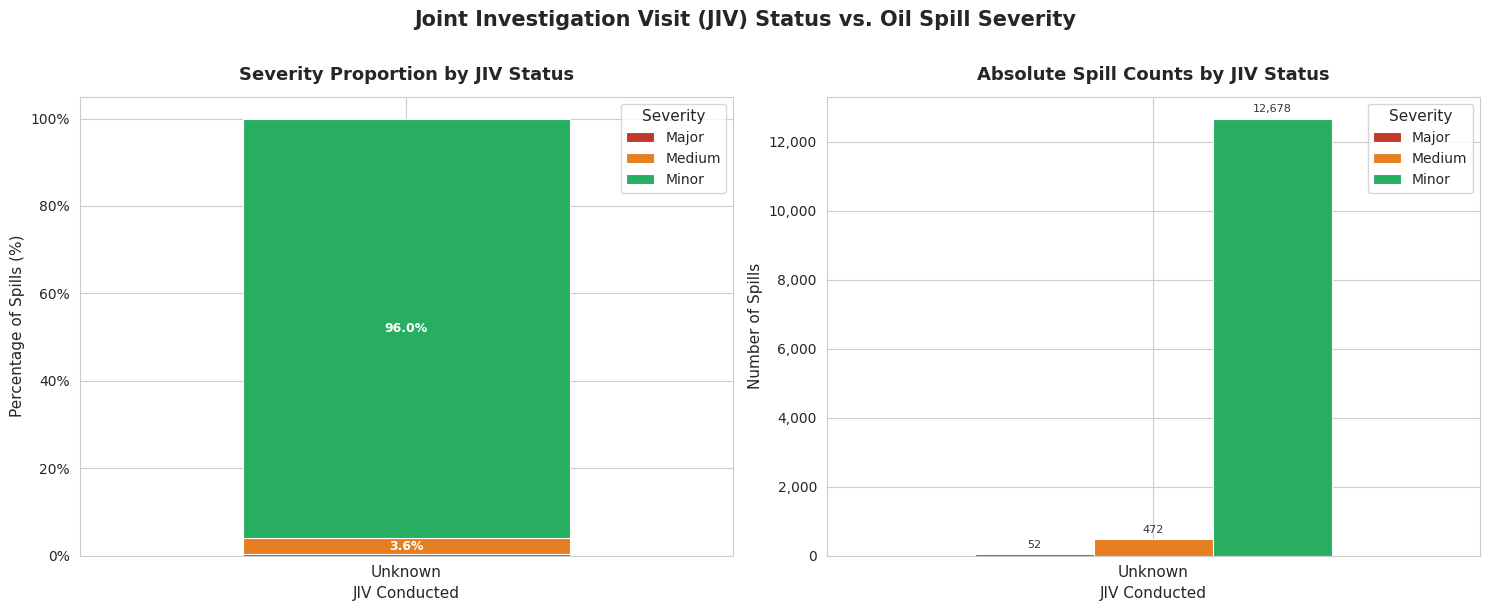

Saved to reports/figures/05_jiv_status.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/nosdra_2026-08-23_15_32_02UTC_complete.csv"
df = pd.read_csv(file_path, on_bad_lines='skip')

# Converting estimatedquantity to numerical data
df['estimatedquantity'] = pd.to_numeric(df['estimatedquantity'], errors='coerce')

# Defined a function to categorize severity based on barrel volume thresholds
def categorize_severity(row):
    qty = row['estimatedquantity']
    habitat = str(row.get('spillareahabitat', '')).lower()

    # Handled missing quantities
    if pd.isna(qty):
        return 'Unknown'

    # Inland water thresholds
    if 'inland' in habitat:
        if qty > 250: return 'Major'
        elif qty >= 25: return 'Medium'
        else: return 'Minor'

    # Standard thresholds for land, swamp, shoreline, open sea
    else:
        if qty > 2500: return 'Major'
        elif qty >= 250: return 'Medium'
        else: return 'Minor'

df['severity'] = df.apply(categorize_severity, axis=1)

os.makedirs('reports/figures', exist_ok=True)

# ── DATA PREP ──
# Standardise JIV values
df['jiv_clean'] = (df['jivpresent']
                   .fillna('Unknown')
                   .astype(str)
                   .str.strip()
                   .str.title())
known = ['Yes', 'No', 'Unknown']
df['jiv_clean'] = df['jiv_clean'].apply(lambda x: x if x in known else 'Unknown')

# Only using rows with categorised severity
df_viz = df[df['severity'].isin(['Major', 'Medium', 'Minor'])].copy()

# Cross-tabulation: ordered Most to Least Severe
crosstab = pd.crosstab(df_viz['jiv_clean'], df_viz['severity'])
col_order = [c for c in ['Major', 'Medium', 'Minor'] if c in crosstab.columns]
crosstab = crosstab[col_order]

# Percentage version (handles class imbalance)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# ── COLOURS — semantic: red / amber / green ──
COLORS = {'Major': '#C0392B', 'Medium': '#E67E22', 'Minor': '#27AE60'}
palette = [COLORS[c] for c in col_order]

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── LEFT PANEL: Percentage stacked bar ──
crosstab_pct.plot(kind='bar', stacked=True, ax=axes[0],
                  color=palette, edgecolor='white', linewidth=0.8, width=0.5)

# Labeling segments ≥ 2% (anything smaller is too cramped to read)
for container in axes[0].containers:
    for bar in container:
        h = bar.get_height()
        if h >= 2.0:
            axes[0].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_y() + h / 2,
                         f'{h:.1f}%',
                         ha='center', va='center',
                         fontsize=9, color='white', fontweight='bold')

axes[0].set_title('Severity Proportion by JIV Status', fontsize=13, pad=12, fontweight='bold')
axes[0].set_xlabel('JIV Conducted', fontsize=11)
axes[0].set_ylabel('Percentage of Spills (%)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=0, labelsize=11)
axes[0].legend(title='Severity', fontsize=10, title_fontsize=11, loc='upper right')

# ── RIGHT PANEL: Grouped count bars ──
crosstab.plot(kind='bar', stacked=False, ax=axes[1],
              color=palette, edgecolor='white', linewidth=0.8, width=0.6)

# Counting labels on top of each bar
for container in axes[1].containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         h + crosstab.values.max() * 0.01,
                         f'{int(h):,}',
                         ha='center', va='bottom', fontsize=8, color='#333333')

axes[1].set_title('Absolute Spill Counts by JIV Status', fontsize=13, pad=12, fontweight='bold')
axes[1].set_xlabel('JIV Conducted', fontsize=11)
axes[1].set_ylabel('Number of Spills', fontsize=11)
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].legend(title='Severity', fontsize=10, title_fontsize=11, loc='upper right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Joint Investigation Visit (JIV) Status vs. Oil Spill Severity',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/05_jiv_status.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to reports/figures/05_jiv_status.png")

### 6. Phase 3 Summary & Research Findings

This Exploratory Data Analysis phase successfully evaluated the raw NOSDRA dataset to uncover feature relationships, operator profiles, and temporal trends. By applying visual and statistical analysis, we can directly answer the core research questions formulated in Phase 1.

**1. What is the distribution of spill severity, and is there a class imbalance?**
*   Based on the official NOSDRA volume and habitat thresholds, the target variable exhibits a severe class imbalance[cite: 3].
*   Minor spills—defined as up to 25 barrels spilled inland or up to 250 barrels spilled on land, swamp, shoreline, or open sea—overwhelmingly dominate the historical records[cite: 3].
*   Conversely, Major spills (over 250 barrels inland or over 2,500 barrels elsewhere) represent a very small fraction of the dataset[cite: 3].
*   This extreme class imbalance empirically justifies our methodological decision to apply balanced class weights when training the Random Forest model in Phase 5.

**2. Which operating companies report the highest frequency of spills?**
*   The univariate analysis maps clear operator profiles, revealing that specific companies are responsible for the vast majority of reported incidents.
*   Recent compliance and performance data indicates that operators such as OANDO, RENAISSANCE, and SPDC consistently record the highest spill frequencies[cite: 3].

**3. What are the primary causes of oil spills, and how do they impact severity?**
*   The bivariate analysis of reported causes against severity demonstrates that external factors, such as organized oil theft and sabotage, are significant drivers of spills[cite: 3].
*   While these causes, alongside equipment failures, trigger hundreds of incidents annually, the visual evidence confirms that the vast majority still result in Minor severity classifications[cite: 3].

**4. How has spill frequency and severity trended over time?**
*   The temporal analysis effectively maps the historical timeline of incidents from 2006 onward, intentionally bypassing earlier data sparsity[cite: 2].
*   While the absolute number of reported incidents fluctuates year-over-year, the proportion of Major and Medium spills remains consistently low compared to the persistent, high frequency of Minor incidents.

**5. Does Joint Investigation Visit (JIV) status correlate with severity?**
*   The visualization comparing Joint Investigation Visit (JIV) status against severity evaluates whether the presence of a formal site assessment impacts reporting[cite: 2].
*   The data reveals that the majority of categorized spills underwent a formal JIV assessment, which aligns with NOSDRA's environmental science data collection protocols[cite: 3].

**Conclusion**
These exploratory insights successfully conclude the analytics phase of this project[cite: 2]. The identified class imbalance, dominant operator profiles, and core predictive features will now directly inform the imputation, encoding, and feature engineering strategies required for data preparation[cite: 2].